## Load in Single Run, get Hamiltonian

In [1]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
pickled_obj = {}

with open('./allplots/sweep_sep3/sep50/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

# femsystem:FEMSystem = pickled_obj["femsystem"]
# femsystem.saveFigsDir = None # Turn OFF saving plots
# u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]

# # Normalize the modes
# u_even = u_even / femsystem.integrate(lambda u,a,b: u**2,u_even)
# u_odd = u_odd / femsystem.integrate(lambda u,a,b: u**2,u_odd)

# u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
# theta_at_dofs = pickled_obj["theta_at_dofs"]
# theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
# parameters = pickled_obj["parameters"]
# totalTime = pickled_obj["totalTime"]

# material = parameters["material"]
# separation = parameters["separation"]
# integrated_volume = pickled_obj["integrated_volume"]
# sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
# volume = 2 * sidelenX * sidelenY * sidelenZ
# print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")

# print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
# print(f"Parameters:")
# print(parameters)

# def alpha(u,A_int,P_int):
#     return 1/(material) * femsystem.double_integral_cg(lambda u1,a,b,c,d: u1**2,lambda u1,a,b,c,d: u1**2,A_int,P_int,u,u)

# # Really u*laplacian(u) = -(grad u)^2
# def laplacian(u,grad_u,x):
#     return -1*jnp.sum(grad_u**2,axis=0)

# def epsilon_func(u_global, P_int, phi_theta_int):
#     # Kinetic Term
#     kinetic = -4 * femsystem.integrate(laplacian,u_global)

#     # Potential Term: -2 * <u^2, G theta> = -2 * <u^2, phi_theta>
#     u_quad = femsystem._interpolate_values(u_global)
#     weighted_u2 = (u_quad**2) * femsystem.weights
#     v_u2 = P_int.T @ weighted_u2.ravel()
#     potential = -2 * (v_u2 @ phi_theta_int)

#     print(f"KE: {kinetic}, PE: {potential}")

#     return kinetic  + potential

# A_int,P_int = femsystem.get_stiffness_matrix()

In [6]:
def get_H(n,E_J,E_C,plot=False):
    # Copy these three matrix construction functions from 3DTwoModesOpt.py
    x = (n-1)/2 - jnp.arange(n) # Charge Imbalance Eigenvalue, centered at 0 

    def n_operator(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals)

    def Jz2(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals**2)

    def off_diag(n,k):
        ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
        super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
        result = super_diag_matrix + sub_diag_matrix
        return result 

    def cos_phi(n):
        return off_diag(n,1) / 2

    hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) # No need for e_0 term, since we are only interested in eigenvectors

    def time_dependent_H(t,g,omega):
        return  hamiltonian + g * jnp.sin(omega * t) * n_operator(n)

    return time_dependent_H


# Get Hamiltonian
H = get_H(n,E_J,E_C)

# Get Eigenvalues and Eigenvectors
eigenvalues,eigenvectors = jnp.linalg.eigh(H(0,1,1)) # Just at time = 0

# Need the energy splitting and the initial state
psi0 = np.array(eigenvectors[:,0],dtype=complex)
psi1 = np.array(eigenvectors[:,1],dtype=complex)
omega = eigenvalues[1] - eigenvalues[0]
g = 5

td_H = lambda t: H(t,g,omega)

# General Schrodinger Equation Solving

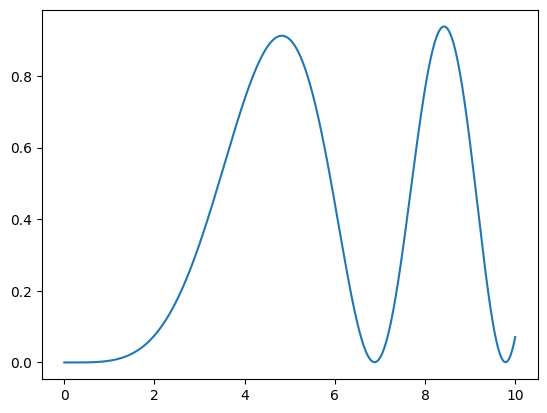

In [7]:
import numpy as np
from scipy.integrate import solve_ivp

# Define the diff eq system (right side of eq)
def schrodinger_eq(t, psi):
    # Note: solve_ivp expects (t, y) signature
    return -1j * td_H(t) @ psi

# Solve the diff eq
t_span = (0, 10)  # Start and end time
t_eval = np.linspace(0, 10, 1000)  # Times where we want the solution saved

sol = solve_ivp(schrodinger_eq, t_span, psi0, t_eval=t_eval, method='RK45')

# sol.y is a matrix where each column is the state at a different time
# sol.t contains the time points

one_state_amplitudes = [ abs(state @ psi1)**2 for state in sol.y.T]
plt.plot(sol.t,one_state_amplitudes)